In [2]:
# import goes here
import pandas as pd
import os
import matplotlib.pyplot as plt
import time
import seaborn as sns
import mlflow
import uuid
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

## Basic EDA

In [3]:
df = pd.read_csv("../data/income_data.csv", index_col=False)

In [4]:
print(df.head(), "\n")
print(df.info(), "\n")
print(df.describe(), "\n")

           Workclass   Education       Marital-Status          Occupation  \
0          State-gov   Bachelors        Never-married        Adm-clerical   
1   Self-emp-not-inc   Bachelors   Married-civ-spouse     Exec-managerial   
2            Private     HS-grad             Divorced   Handlers-cleaners   
3            Private        11th   Married-civ-spouse   Handlers-cleaners   
4            Private   Bachelors   Married-civ-spouse      Prof-specialty   

     Relationship    Race      Sex  Native_country  Target  
0   Not-in-family   White     Male   United-States   <=50K  
1         Husband   White     Male   United-States   <=50K  
2   Not-in-family   White     Male   United-States   <=50K  
3         Husband   Black     Male   United-States   <=50K  
4            Wife   Black   Female            Cuba   <=50K   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------      

In [6]:
if not os.path.exists("categorical_variable_plots"):
    os.makedirs("categorical_variable_plots")

for i in df.iloc[:, :-1].select_dtypes(include="object").columns:
    print(f"Variable: {i} \n")
    # print(df[i].value_counts())

    fig, ax = plt.subplots(figsize=(8, 6), dpi=500)
    f = sns.histplot(
        data=df, y=i, multiple="fill", hue="Target", fill=True, stat="density", ax=ax
    )
    plt.tight_layout()
    fig.savefig(f"categorical_variable_plots/Variable {i}.png")
    plt.close()

Variable: Workclass 

Variable: Education 

Variable: Marital-Status 

Variable: Occupation 

Variable: Relationship 

Variable: Race 

Variable: Sex 

Variable: Native_country 



## Setting Up MLflow

In [5]:
# Setup tracking uri and experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("income_classifier")

<Experiment: artifact_location='mlflow-artifacts:/699166571264602312', creation_time=1777641702245, experiment_id='699166571264602312', last_update_time=1777641702245, lifecycle_stage='active', name='income_classifier', tags={}>

In [ ]:
with mlflow.start_run(run_name=f"eda-{uuid.uuid4()}"):
    for i in df.iloc[:, :-1].select_dtypes(include="object").columns:
        # print(f"Variable: {i} \n")
        # print(df[i].value_counts())

        fig, ax = plt.subplots(figsize=(8, 6))
        f = sns.histplot(
            data=df,
            y=i,
            multiple="fill",
            hue="Target",
            fill=True,
            stat="density",
            ax=ax,
        )
        plt.tight_layout()
        fig.savefig(f"categorical_variable_plots/Variable {i}.png")
        mlflow.log_artifact("categorical_variable_plots")
        plt.close()

Variable: Workclass 

Variable: Education 

Variable: Marital-Status 

Variable: Occupation 

Variable: Relationship 

Variable: Race 

Variable: Sex 

Variable: Native_country 



## Model Training

In [7]:
target = df.Target
feature_df = df.drop("Target", axis=1)

encoder = OneHotEncoder(sparse_output=False, drop="if_binary")
target = encoder.fit_transform(np.array(target).reshape(-1, 1))

dummyfied_df = pd.get_dummies(
    feature_df,
    drop_first=True,
    sparse=False,
    dtype=float,
)
col_list = dummyfied_df.columns.tolist()
with open("column_list.pkl", "wb") as f:
    pickle.dump(col_list, f)

X_train, X_test, y_train, y_test = train_test_split(
    dummyfied_df, target, test_size=0.8, shuffle=True
)

Utils

In [8]:
def save_df_to_file(df, bucket_name, path):
    if not os.path.exists(f"./buckets/{bucket_name}"):
        os.makedirs(f"./buckets/{bucket_name}/{os.path.dirname(path)}")

    df.to_csv(f"./buckets/{bucket_name}/{path}", index=False)

### Decision tree classifier

In [10]:
BUCKET_NAME = "mlflow-datasets"

In [ ]:
with mlflow.start_run() as run:
    results = pd.DataFrame(
        index=[
            "Roc Auc Score test",
            "Accuracy score train",
            "Accuracy score test",
            "time to fit",
        ]
    )
    tree = DecisionTreeClassifier()
    run_id = run.info.run_id

    # Save feature
    feature_df_path = f"income-classifier-datasets/feature_df-{run_id}.csv"
    save_df_to_file(feature_df, BUCKET_NAME, feature_df_path)

    # Save train df
    train_df = pd.concat([X_train, pd.Series(y_train.ravel())], axis=1)
    train_df_path = f"income-classifier-datasets/train-{run_id}.csv"
    save_df_to_file(train_df, BUCKET_NAME, train_df_path)

    # Save test df
    test_df = pd.concat([X_test, pd.Series(y_test.ravel())], axis=1)
    test_df_path = f"income-classifier-datasets/test-{run_id}.csv"
    save_df_to_file(test_df, BUCKET_NAME, test_df_path)

    # Convert Pandas df to MLflow df
    training_dataset = mlflow.data.from_pandas(
        train_df, source=f"./buckets/{BUCKET_NAME}/{train_df_path}"
    )

    test_dataset = mlflow.data.from_pandas(
        test_df, source=f"./buckets/{BUCKET_NAME}/{test_df_path}"
    )

    feature_dataset = mlflow.data.from_pandas(
        feature_df, source=f"./buckets/{BUCKET_NAME}/{feature_df_path}"
    )

    # Logs MLflow df to MLflow
    mlflow.log_input(training_dataset, context="training")
    mlflow.log_input(test_dataset, context="testing")
    mlflow.log_input(feature_dataset, context="reference")

    # Fit the model and log metrics
    tree.fit(X_train, y_train.ravel())

    roc_auc_score_train = roc_auc_score(y_train == 1, tree.predict_proba(X_train)[:, 1])
    roc_auc_score_test = roc_auc_score(y_test == 1, tree.predict_proba(X_test)[:, 1])
    
    training_accuracy = tree.score(X_train, y_train)
    test_accuracy = tree.score(X_test, y_test)
    
    mlflow.log_metric("roc_auc_score_train", roc_auc_score_train)
    print(f"Roc Auc Score train: {roc_auc_score_train}\n")
    
    mlflow.log_metric("roc_auc_score_test", roc_auc_score_test)
    print(f"Roc Auc Score test: {roc_auc_score_test}\n")
    
    mlflow.log_metric("training_accuracy", training_accuracy)
    print(f"Accuracy train: {training_accuracy}")
    
    mlflow.log_metric("test_accuracy", test_accuracy)
    print(f"Accuracy test: {test_accuracy}")
    
    mlflow.sklearn.log_model(tree, "income-classifier")
    mlflow.log_params(tree.get_params())
    

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\data\dataset_source_registry.py:142: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\data\digest_utils.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\data\dataset_source_registry.py:142: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\

Roc Auc Score train: 0.9555125499108399

Roc Auc Score test: 0.7911376983836759

Accuracy train: 0.8889257294429708
Accuracy test: 0.8038126813095732


### Random Forest Classifier

In [11]:
with mlflow.start_run() as run:
    forest=RandomForestClassifier()

    start=time.time()
    run_id = run.info.run_id
    train_df = pd.concat([X_train,pd.Series(y_train.ravel())],axis=1)
    test_df = pd.concat([X_test,pd.Series(y_test.ravel())],axis=1)
    feature_df_path = f"income-classifier-datasets/feature_df-{run_id}.csv"
    train_df_path = f"income-classifier-datasets/train-{run_id}.csv"
    test_df_path = f"income-classifier-datasets/test-{run_id}.csv"
    save_df_to_file(train_df,BUCKET_NAME,train_df_path)
    save_df_to_file(feature_df,BUCKET_NAME,feature_df_path)
    save_df_to_file(test_df,BUCKET_NAME,test_df_path)
    feature_dataset = mlflow.data.from_pandas(feature_df, source=f"{BUCKET_NAME}/{feature_df_path}")
    training_dataset = mlflow.data.from_pandas(train_df, source=f"{BUCKET_NAME}/{train_df_path}")
    test_dataset = mlflow.data.from_pandas(test_df, source=f"{BUCKET_NAME}/{test_df_path}")
    
    # Logs MLflow df to MLflow
    mlflow.log_input(training_dataset,context="training")
    mlflow.log_input(test_dataset,context="testing")
    mlflow.log_input(feature_dataset,context="reference_features")
    forest.fit(X_train, y_train.ravel())
    end=time.time()

    # Compute and log metrics 
    roc_auc_score_train = roc_auc_score(y_train==1, forest.predict_proba(X_train)[:,1])
    roc_auc_score_test = roc_auc_score(y_test==1, forest.predict_proba(X_test)[:,1])
    training_accuracy = forest.score(X_train, y_train)
    test_accuracy = forest.score(X_test, y_test)
    
    mlflow.log_artifact("column_list.pkl")
    mlflow.log_metric("roc_auc_score_train",roc_auc_score_train)
    print(f'Roc Auc Score train: {roc_auc_score_train}  \n')
    mlflow.log_metric("roc_auc_score_test",roc_auc_score_test)
    print(f'Roc Auc Score test: {roc_auc_score_test}  \n')
    mlflow.log_metric("training_accuracy",training_accuracy)
    print(f'Accuracy train : {training_accuracy}')
    mlflow.log_metric("test_accuracy",test_accuracy)
    print(f'Accuracy test : {test_accuracy}')
    mlflow.sklearn.log_model(forest,"income-classifier")
    
    mlflow.log_params(forest.get_params())

Roc Auc Score train: 0.9487572736012895  

Roc Auc Score test: 0.8447188580617956  

Accuracy train : 0.8837864721485411
Accuracy test : 0.8112308329879818


### XGBoost classifier

2026/05/01 15:21:29 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during xgboost autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID efe5248927f743278fd271ec1af20119. Failed operations: [MlflowException("API request to http://127.0.0.1:5000/api/2.0/mlflow/runs/log-batch failed with exception HTTPConnectionPool(host=\'127.0.0.1\', port=5000): Max retries exceeded with url: /api/2.0/mlflow/runs/log-batch (Caused by ResponseError(\'too many 500 error responses\'))")]')]


Roc Auc Score train: 0.8151834031584457  

Roc Auc Score test: 0.71912639527312  

Accuracy train : 0.876657824933687
Accuracy test : 0.8067965188561956


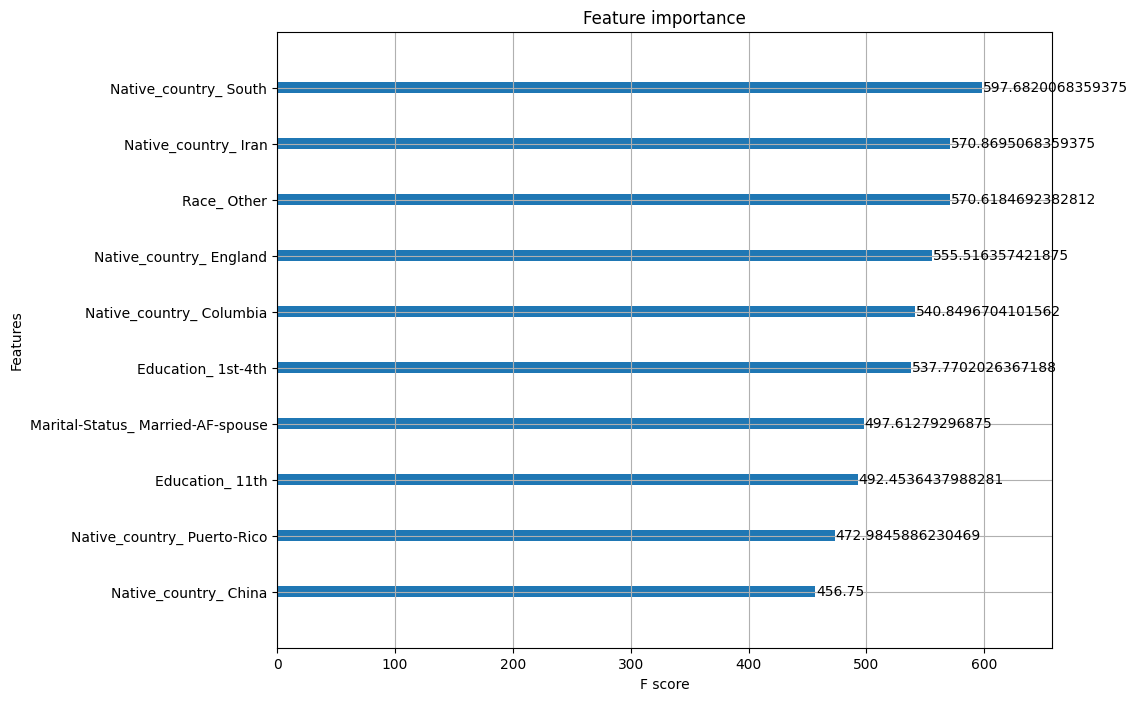

In [12]:
with mlflow.start_run() as run:
    mlflow.xgboost.autolog()
    n_round=30
    run_id = run.info.run_id
    
    # Prepare data and log to MLflow
    dtrain= xgb.DMatrix(data=X_train, label=y_train.ravel())
    dtest= xgb.DMatrix(data=X_test, label=y_test.ravel())
    params={"objective":"binary:logistic",'colsample_bytree': 1,'learning_rate': 1,
                    'max_depth': 10 , 'subsample':1}
    model=xgb.train(params,dtrain, n_round)
    ax = xgb.plot_importance(model, max_num_features=10, importance_type='cover')
    fig = ax.figure
    fig.set_size_inches(10, 8)
    pred_train= model.predict(dtrain)
    pred_test=model.predict(dtest)
    model=xgb.train(params={"objective":"binary:hinge",'colsample_bytree': 1,'learning_rate': 1,
                    'max_depth': 10 , 'subsample':1}, dtrain=dtrain)
    
    # Make prediction
    pred_train= model.predict(dtrain)
    pred_test=model.predict(dtest)
    
    # Compute and log metrics
    roc_auc_score_train = roc_auc_score(y_train==1, pred_train)
    roc_auc_score_test = roc_auc_score(y_test==1, pred_test)
    training_accuracy = accuracy_score(y_train, pred_train)
    test_accuracy = accuracy_score(y_test, pred_test)
    
    mlflow.log_metric("roc_auc_score_train",roc_auc_score_train)
    mlflow.log_artifact("column_list.pkl")
    print(f'Roc Auc Score train: {roc_auc_score_train}  \n')
    
    mlflow.log_metric("roc_auc_score_test",roc_auc_score_test)
    print(f'Roc Auc Score test: {roc_auc_score_test}  \n')
    
    mlflow.log_metric("training_accuracy",training_accuracy)
    print(f'Accuracy train : {training_accuracy}')
    
    mlflow.log_metric("test_accuracy",test_accuracy)
    print(f'Accuracy test : {test_accuracy}')

### Select best model

In [15]:
mlflow_client = mlflow.MlflowClient()

experiment_name = "income_classifier"
experiment = mlflow_client.get_experiment_by_name(experiment_name)

run_object = mlflow_client.search_runs(
    experiment_ids=experiment.experiment_id, 
    filter_string="metrics.roc_auc_score_test > 0.8", 
    max_results=1, 
    order_by=["metrics.roc_auc_score_test DESC"]
)[0]

model_uri = f"runs:/{run_object.info.run_id}/{experiment_name}" 
mlflow.register_model(model_uri, "random_forest_classifier")

Successfully registered model 'random_forest_classifier'.
2026/05/01 15:28:31 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest_classifier, version 1
Created version '1' of model 'random_forest_classifier'.


<ModelVersion: aliases=[], creation_timestamp=1777645711869, current_stage='None', description='', last_updated_timestamp=1777645711869, name='random_forest_classifier', run_id='fd44c1e908304305aba35647f157e41f', run_link='', source='mlflow-artifacts:/699166571264602312/fd44c1e908304305aba35647f157e41f/artifacts/income_classifier', status='READY', status_message='', tags={}, user_id='', version='1'>